In [2]:
import sys
sys.path.append('..')

from LiLY.modules.tv_golem import GolemModel
import torch
import torch.nn as nn
import torch.optim as optim
import os, pwd
import cartopy.crs as ccrs
import cartopy
import numpy as np
import matplotlib.pyplot as plt 
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import argparse
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import ipdb
import pytorch_lightning as fpl
import wandb
from pytorch_lightning.loggers import WandbLogger
from einops import repeat

from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import Dataset, DataLoader, random_split
from datetime import datetime
from tqdm import tqdm
from einops import repeat

from Caulimate.Data.SimLinGau import LinGauSuff
from Caulimate.Data.SimDAG import simulate_random_dag, simulate_weight, simulate_time_vary_weight
from Caulimate.Utils.Visualization import save_DAG, make_dots, plot_causal_graph, quick_map
from Caulimate.Utils.Tools import check_tensor, check_array, load_yaml, makedir, lin_reg_init, dict_to_class, save_log, bin_mat, center_and_norm, get_free_gpu
from Caulimate.Utils.GraphMetric import count_graph_accuracy
from Caulimate.Data.CESM2.dataset import CESM2_grouped_dataset, downscale_dataset
from Caulimate.Utils.GraphUtils import eudistance_mask, decycle_till_dag

DATA_DIR = os.path.join(os.environ.get('DATASET_DIR'), 'CESM2') # you could modify it to your path
DOWNSCALE_PATH = os.path.join(DATA_DIR, 'downscaled_pacific_CESM2.txt')
DOWNSCALE_METADATA_PATH = os.path.join(DATA_DIR, 'downscaled_metadata.pkl')

# if torch.cuda.is_available():   
#     os.environ["CUDA_VISIBLE_DEVICES"] = get_free_gpu()
#     print(f"--- Selected GPU: {os.environ["CUDA_VISIBLE_DEVICES"]}")


args = {
    'data_path': "/l/users/minghao.fu/dataset/CESM2/CESM2_pacific_grouped_SST.nc",
    'noise_type': 'gaussian_ev',
    'load_data': True,
    'graph_type': 'ER',
    'num': 6000,
    'scale': 0.5,
    'pi': 10,
    'd_X': None,
    'degree': 4,
    'cos_len': 1000,
    'max_eud': 40,
    'equal_variances': True,

    'train': True,
    'pretrain': False,
    'checkpoint_path': None,
    'regression_init': False,
    'loss': {
        'likelihood': 1.0,
        'L1': 1.e-2,
        'dag': 1.e-2
    },
    'reg_thres': 0.05,
    'ddp': False,
    'pre_epoch': 0,
    'epoch': 10000,
    'init_epoch': 100,
    'batch_size': 64,
    'lag': 10,
    'synthetic': False,
    'time_varying': False,
    'sparse': False,

    'seed': 2,
    'gt_init': False,
    'embedding_dim': 5,
    'spectral_norm': False,
    'tol': 0.0,
    'graph_thres': 0.3,
    'DAG': 0.8,
    'save_dir': "/l/users/minghao.fu/logs/ClimateModel/LinGau/CESM2",

    'condition': "ignavier",
    'decay_type': "step",
    'optimizer': "ADAM",
    'weight_decay': 0.0,
    'lr': 1.e-4,
    'gradient_noise': None,
    'step_size': 1000,
    'gamma': 0.5,
    'decay': [200, 400, 800, 1000],
    'betas': [0.9, 0.999],
    'epsilon': 1.e-8,
    'momentum': 0.9
}

#

args = dict_to_class(**args)
# init with eud mask
save_test_dir = './downscale_CESM2_eud_mask'

/fsx/homes/Minghao.Fu@mbzuai.ac.ae/.conda/envs/fmh/lib/python3.8/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [3]:
dataset = downscale_dataset(path=DOWNSCALE_PATH, metadata_path=DOWNSCALE_METADATA_PATH)#CESM2_grouped_dataset(args.data_path, num_area=1)[0]
args.d_X = dataset.d_X
args.num = dataset.n_samples
eud_mask = eudistance_mask(dataset.coords, args.max_eud)
wandb_logger = WandbLogger(project='golem', name=datetime.now().strftime("%Y%m%d-%H%M%S"))
rs = np.random.RandomState(args.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print('--- Mask by neighbor constraint: \n------ num: {}\n------ ratio: {}'.format(int(eud_mask.sum()), eud_mask.sum() / args.d_X ** 2))

# X = check_tensor(X, dtype=torch.float32)
# X = X - X.mean(dim=0)
# T = check_tensor(torch.arange(X.shape[0]), dtype=torch.float32).reshape(-1, 1)
# coords = repeat(check_tensor(coords, dtype=torch.float32), 'j k -> i j k', i=X.shape[0])   
# Bs = check_tensor(Bs, dtype=torch.float32)
# dataset = TensorDataset(X, T, Bs, coords)

B_init, reg_mask = lin_reg_init(center_and_norm(dataset.X), thres=args.reg_thres, mask=eud_mask)
B_init = check_tensor(B_init, dtype=torch.float32)
print('--- B_init: \n {}'.format(B_init))
reg_mask = bin_mat(B_init)
print('--- Mask by regression: \n------ num: {} \n------ ratio: {}'.format(int(reg_mask.sum()), reg_mask.sum() / args.d_X ** 2))

mask = eud_mask * reg_mask
print('--- Mask in training: \n------ num: {} \n------ ratio: {}'.format(int(mask.sum()), mask.sum() / args.d_X ** 2))
_Bs_gt = check_tensor(mask, dtype=torch.float32)
Bs_gt = repeat(_Bs_gt, 'j k -> i j k', i=dataset.n_samples)

makedir(save_test_dir)
np.save(os.path.join(save_test_dir, 'mask.npy'), mask)
np.save(os.path.join(save_test_dir, 'B_init.npy'), B_init)
np.save(os.path.join(save_test_dir, 'coords.npy'), dataset.coords)

--- Mask by neighbor constraint: 
------ num: 2130
------ ratio: 0.3167757287328971
--- Linear regression initialization


100%|██████████| 82/82 [36:28<00:00, 26.69s/it]

--- Linear regression init loss: 0.03806730732321739
--- B_init: 
 tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.2023, 0.0000, 0.1430,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1130, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0712],
        [0.0000, 0.0000, 0.0000,  ..., 0.2806, 0.0000, 0.4478],
        [0.0000, 0.0000, 0.0000,  ..., 0.0510, 0.3541, 0.0000]])
--- Mask by regression: 
------ num: 1457 
------ ratio: 0.21668649613325403
--- Mask in training: 
------ num: 1457 
------ ratio: 0.21668649613325403


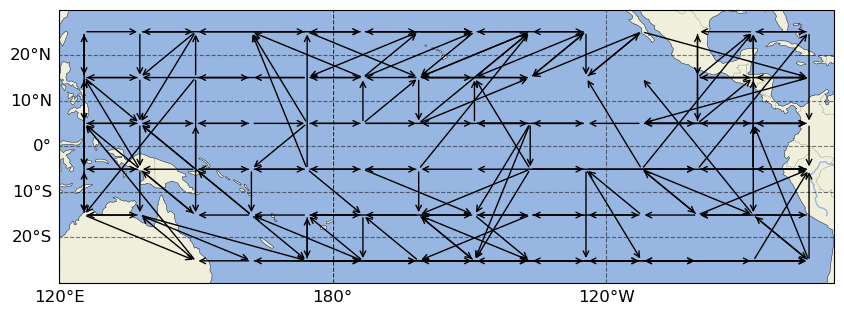

In [5]:


mask = np.load(os.path.join(save_test_dir, 'mask.npy'))
B_init = np.load(os.path.join(save_test_dir, 'B_init.npy'))
coords = np.load(os.path.join(save_test_dir, 'coords.npy'))

B_init[np.abs(B_init) < 0.185] = 0    
center=180
# Assuming coords is a list of tuples, where each tuple is (lat, lon)
adjusted_coords = [(lat, 180 - lon if lon <= 180 else lon - 180) for lat, lon in coords]

fig, ax = plt.subplots(1, 1, figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=center)})
ax.add_feature(cartopy.feature.LAND)
ax.add_feature(cartopy.feature.OCEAN)
ax.add_feature(cartopy.feature.COASTLINE,linewidth=0.3)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':',linewidth=0.3)
ax.add_feature(cartopy.feature.LAKES, alpha=0.5)
ax.add_feature(cartopy.feature.RIVERS)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
gl = ax.gridlines(draw_labels=True, color='black', alpha=0.5, linestyle='--')
gl.top_labels = False  # Disable labels at the top
gl.right_labels = False  # Disable labels on the right
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

def offset_path(start, end, offset):
    start_lon, start_lat = start
    end_lon, end_lat = end
    mid_lon = (start_lon + end_lon) / 2 + offset
    mid_lat = (start_lat + end_lat) / 2 + offset
    return [(start_lon, start_lat), (mid_lon, mid_lat), (end_lon, end_lat)]

# 根据邻接矩阵绘制因果连接
offset = 0.5  # 偏移量

for i in range(len(B_init)):
    for j in range(len(B_init)):
        if B_init[i, j] != 0:
            point1 = coords[i]
            point2 = coords[j]
            # 处理跨越日期变更线的情况
            # if abs(point1[1] - point2[1]) > 180:
            #     if point1[1] > point2[1]:
            #         point2 = (point2[0], point2[1] + 360)
            #     else:
            #         point1 = (point1[0], point1[1] + 360)
            path = offset_path(point1, point2, offset * (i + j))
            xs, ys = zip(*path)
            ax.plot(xs, ys, color='red', linewidth=1, transform=ccrs.PlateCarree())
            ax.annotate('', xy=(point2[1], point2[0]), xytext=(point1[1], point1[0]),
                        arrowprops=dict(facecolor='red', arrowstyle='->', lw=1, connectionstyle="arc3"),
                        transform=ccrs.PlateCarree())
            

for lat, lon in coords:
    ax.annotate('', xy=(lon - 180, lat), xytext=(lon - 180, lat),
                            arrowprops=dict(facecolor='red', arrowstyle='->', lw=1))
ax.set_extent([120, 290, -30, 30], crs=ccrs.PlateCarree())
plt.savefig(os.path.join(save_test_dir, 'LinRegInit.pdf'), format='pdf', bbox_inches='tight')

In [6]:
import math

def euclidean_distance(point1, point2):
    return math.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

# Test the function
point1 = (-25.13089, 149.95535)
point2 = (-15.078534, 125.49107)
distance = euclidean_distance(point1, point2)
print(f"The distance is {distance} units.")

The distance is 26.449023745105166 units.
